# 08 — Story class and event-type conditioning

**Estimand.** Type-specific slope of the development-only, economically
oriented `negative_share` signal against exact next-session `ar_open_h1`.

**Design.** One pooled model with 12 type intercepts and 12 type slopes;
session-date clustered standard errors; BH-FDR over 12 slopes × h1. The event
taxonomy and breaking/repetition/routine candidate classes are deterministic
regex/novelty outputs. They are explicitly **provisional** because the seeded
180-story human audit is not labelled. No evaluation rows select a type.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.event_types import (  # noqa: E402
    AUDIT_N,
    AUDIT_SEED,
    TYPE_FAMILY,
    build_event_type_artifacts,
    pooled_type_slopes,
)
from final_experiments.lib.panel import DEFAULT_EVENTS_DB  # noqa: E402

OUTPUT = REPO_ROOT / "final_experiments" / "outputs" / "08_story_type"
OUTPUT.mkdir(parents=True, exist_ok=True)
AGG_PATH = REPO_ROOT / "final_experiments" / "outputs" / "03_aggregation" / "firm_day_aggregators.parquet"
NOVELTY_PATH = REPO_ROOT / "final_experiments" / "outputs" / "02_filters_and_distribution" / "story_novelty.parquet"

print("estimand: type-specific oriented-negative-share slope vs ar_open_h1")
print("split: development through 2019-12-31")
print("cluster: session_date")
print("multiplicity:", TYPE_FAMILY)
print(f"audit: seed={AUDIT_SEED}, target n={AUDIT_N}, human labels required")

estimand: type-specific oriented-negative-share slope vs ar_open_h1
split: development through 2019-12-31
cluster: session_date
multiplicity: 12 dominant event types x h1; BH-FDR q=0.05
audit: seed=20260731, target n=180, human labels required


## Build provisional story classes and dominant firm-day types

In [2]:
firm_day_types, class_mix, audit = build_event_type_artifacts(
    DEFAULT_EVENTS_DB,
    NOVELTY_PATH,
)
firm_day_types.to_parquet(OUTPUT / "firm_day_story_types.parquet", index=False)
class_mix.to_csv(OUTPUT / "story_class_event_type_mix.csv", index=False)
audit.to_csv(OUTPUT / "story_type_audit_sample.csv", index=False)
print(f"typed firm-days={len(firm_day_types):,}; audit rows={len(audit):,}")
print("audit human labels populated:", int(audit["human_event_type"].astype(bool).sum()))
display(class_mix.sort_values("stories", ascending=False).head(20))

/Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/lib/event_types.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hit = unmatched & text.str.contains(pattern, na=False)


/Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/lib/event_types.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  routine = events["event_type"].eq("earnings_guidance") & events["headline"].fillna("").str.contains(_ROUTINE_PATTERN, na=False)


typed firm-days=715,546; audit rows=180
audit human labels populated: 0


,event_type,story_class_candidate,stories,symbols,sessions,mean_abs_score,market_recap_share
21,other,breaking_candidate,501959,570,3262,0.268530,0.059708
13,macro_sector,breaking_candidate,268220,570,3262,0.305088,0.144698
6,earnings_guidance,routine_candidate,197998,570,3203,0.473932,0.117910
4,earnings_guidance,breaking_candidate,148941,570,3259,0.454395,0.077628
0,analyst_rating,breaking_candidate,147561,570,3257,0.390163,0.043433
17,market_price_technical,breaking_candidate,124027,570,3262,0.384386,0.207866
2,commodity_rates_fx,breaking_candidate,39201,562,3239,0.423750,0.165225
19,mna_strategy,breaking_candidate,39177,570,3239,0.366138,0.080991
23,product_technology,breaking_candidate,35358,566,3199,0.340587,0.043187
15,management_governance,breaking_candidate,25977,570,3117,0.193950,0.032298


## Pooled type interaction

`other` is not selected as a reference: the full-rank parameterisation gives
every type its own intercept and slope inside one pooled regression.

,event_type,slope,se,t,p,n_firm_days,n_dates,bh_reject_q05,multiplicity_family,estimand,cluster
7,commodity_rates_fx,0.001593,0.000689,2.310445,0.020864,13520,2225,False,12 dominant event types x h1; BH-FDR q=0.05,type-specific slope of oriented negative_share...,session_date
0,earnings_guidance,0.000391,0.000237,1.650746,0.098790,110665,2264,False,12 dominant event types x h1; BH-FDR q=0.05,type-specific slope of oriented negative_share...,session_date
9,market_price_technical,0.000541,0.000426,1.270143,0.204034,30600,2262,False,12 dominant event types x h1; BH-FDR q=0.05,type-specific slope of oriented negative_share...,session_date
4,product_technology,-0.000798,0.000653,-1.222106,0.221668,10005,2102,False,12 dominant event types x h1; BH-FDR q=0.05,type-specific slope of oriented negative_share...,session_date
1,analyst_rating,0.000321,0.000324,0.991608,0.321389,64574,2263,False,12 dominant event types x h1; BH-FDR q=0.05,type-specific slope of oriented negative_share...,session_date
10,generic_low_information,-0.002072,0.002136,-0.970348,0.331873,2172,1087,False,12 dominant event types x h1; BH-FDR q=0.05,type-specific slope of oriented negative_share...,session_date
6,macro_sector,0.000206,0.000254,0.810865,0.417443,81239,2264,False,12 dominant event types x h1; BH-FDR q=0.05,type-specific slope of oriented negative_share...,session_date
3,legal_regulatory,0.000566,0.000838,0.675315,0.499476,5460,1734,False,12 dominant event types x h1; BH-FDR q=0.05,type-specific slope of oriented negative_share...,session_date
2,mna_strategy,0.000243,0.000739,0.328263,0.742713,13778,2187,False,12 dominant event types x h1; BH-FDR q=0.05,type-specific slope of oriented negative_share...,session_date
11,other,-0.000045,0.000200,-0.224062,0.822709,169028,2264,False,12 dominant event types x h1; BH-FDR q=0.05,type-specific slope of oriented negative_share...,session_date


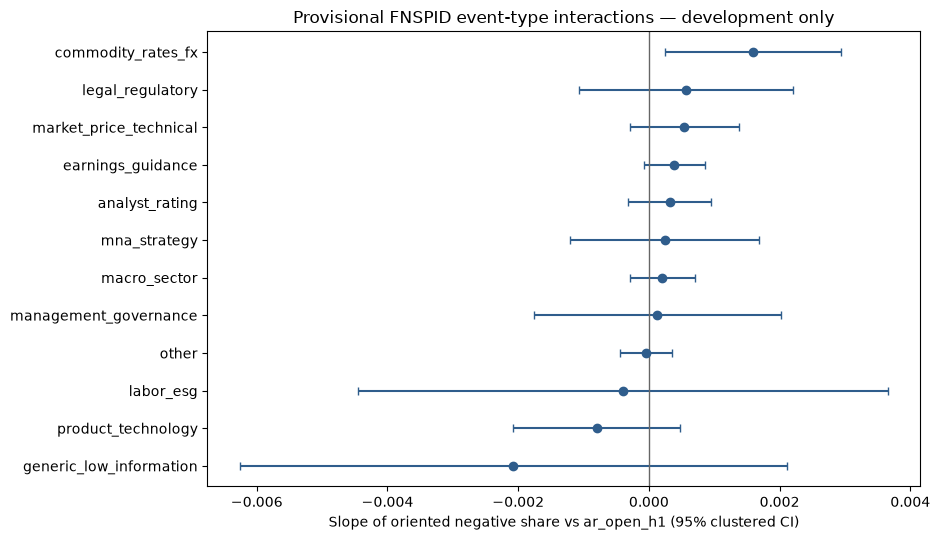

In [3]:
agg = pd.read_parquet(AGG_PATH)
analysis = agg.merge(firm_day_types, on=["symbol", "session_date"], how="inner")
dev = analysis.loc[analysis["split"] == "development"].copy()
slopes = pooled_type_slopes(dev)
slopes.to_csv(OUTPUT / "development_type_interactions.csv", index=False)
display(slopes.sort_values("p").round(6))

ordered = slopes.sort_values("slope")
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.errorbar(
    ordered["slope"],
    range(len(ordered)),
    xerr=1.96 * ordered["se"],
    fmt="o",
    color="#2f5d8c",
    capsize=3,
)
ax.axvline(0, color="#666", lw=1)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(ordered["event_type"])
ax.set_xlabel("Slope of oriented negative share vs ar_open_h1 (95% clustered CI)")
ax.set_title("Provisional FNSPID event-type interactions — development only")
fig.tight_layout()
fig.savefig(OUTPUT / "development_type_interactions.png", dpi=150)
plt.show()

## Conditional type weighting gate

A type-weighted aggregator is allowed only if at least one of the 12 slopes
survives the declared correction. The status below is generated, not inferred
from visual inspection.

In [4]:
n_survive = int(slopes["bh_reject_q05"].sum())
conditional = pd.DataFrame(
    [
        {
            "eligible": n_survive > 0,
            "bh_surviving_type_slopes": n_survive,
            "action": (
                "type-weighted aggregator may be specified in a new frozen arm"
                if n_survive > 0
                else "retain unweighted default; do not create a type-weighted aggregator"
            ),
            "audit_status": "BLOCKED_PENDING_HUMAN_LABELS",
        }
    ]
)
conditional.to_csv(OUTPUT / "type_weighting_gate.csv", index=False)
display(conditional)

manifest = {
    "status": "PROVISIONAL_MACHINE_CLASSIFICATION",
    "estimand": "type-specific slope of oriented negative_share vs ar_open_h1",
    "split": "development <= 2019-12-31",
    "cluster": "session_date",
    "multiplicity_family": TYPE_FAMILY,
    "audit_seed": AUDIT_SEED,
    "audit_n": len(audit),
    "human_labels_present": 0,
    "bh_surviving_type_slopes": n_survive,
    "limitations": [
        "12-type regex taxonomy has not passed the seeded FNSPID human audit",
        "breaking and routine are candidate labels, not validated classes",
        "market recap remains an orthogonal flag and is not treated as routine reporting",
        "publisher and story-family fields are absent on FNSPID checkpoint grain",
    ],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

,eligible,bh_surviving_type_slopes,action,audit_status
0,False,0,retain unweighted default; do not create a typ...,BLOCKED_PENDING_HUMAN_LABELS


{
  "status": "PROVISIONAL_MACHINE_CLASSIFICATION",
  "estimand": "type-specific slope of oriented negative_share vs ar_open_h1",
  "split": "development <= 2019-12-31",
  "cluster": "session_date",
  "multiplicity_family": "12 dominant event types x h1; BH-FDR q=0.05",
  "audit_seed": 20260731,
  "audit_n": 180,
  "human_labels_present": 0,
  "bh_surviving_type_slopes": 0,
  "limitations": [
    "12-type regex taxonomy has not passed the seeded FNSPID human audit",
    "breaking and routine are candidate labels, not validated classes",
    "market recap remains an orthogonal flag and is not treated as routine reporting",
    "publisher and story-family fields are absent on FNSPID checkpoint grain"
  ]
}
